# Introduction to Machine Learning -- MC886
# Assignment 3 - Neural Networks and Overparameterization

**Professor:** Marcelo da Silva Reis  
**PED:** Daniel Gardin Gratti  
**PAD:** Guilherme Henrique Ichiro Seto Ito

In [17]:
# Enter your name and RA number below.
print("Flavia Juliana Ventilari dos Santos", "|", "260438")
print("Student 2", "|", "RA2")
# Remove the line below if your group has only two members.
print("Student 3", "|", "RA3")

Flavia Juliana Ventilari dos Santos | 260438
Student 2 | RA2
Student 3 | RA3


---

## Objective

In Assignment 2 you observed that neural networks can achieve low in-distribution error while failing under distribution shift. This overfitting scenario arises when the model exploits properties present in the training distribution that do not reflect the properties in the underlying data-generating process.

In this assignment, we study how architectural choices and overparameterization interact with inductive bias under distribution shift. In highly parameterized models, multiple distinct mechanisms can explain similar training performance, making it difficult to identify which assumptions about the data are actually responsible for generalization behavior.

For example, a classifier trained on histopathology images may achieve near-perfect training accuracy by either learning morphological features that are stable across imaging sites, or by relying on spurious correlations such as stain-color distributions that coincidentally align with class labels in the training hospitals.
Both solutions fit the training set equally well, but they encode different assumptions about which aspects of the input are relevant, leading to divergent behavior when these correlations are altered or removed in the test distribution.

The goal is to evaluate neural networks as hypothesis classes with different structural assumptions.

### Guidelines

> Please read these guidelines carefully.

1. Answers can be written in English or Portuguese.

2. Use data visualization as a primary tool for understanding. Inspect training data, corrupted inputs, and model behavior. When an assumption is uncertain, verify it empirically through plots.

3. The provided code serves as a reference. Modifications are allowed, including changes to functions and the introduction of new components. Code clarity and organization are required.

4. Use Google Colab or a GPU, if available, to speed up training.

5. The use of generative AI tools (e.g., ChatGPT, GitHub Copilot, DeepSeek, LLaMA) is permitted strictly for **implementation support**. Their use for interpreting, analyzing, or discussing experimental results is discouraged. Submissions must include:
   - A declaration of which models were used.
   - The prompts that generated any incorporated code.

6. Do not hesitate to reach out to the PED/PAD via Discord.

### Experiment structure

Each experiment must follow the structure below:

1. **Question**: the empirical question guiding the exploration.
2. **Hypothesis**: a falsifiable answer to the question that makes a concrete, measurable prediction.
3. **Design**: justify why the proposed experiment can test the hypothesis. Focus on the reasoning, not on how the code works.
4. **Results**: run the experiment and report the metrics.
5. **Discussion**: interpret the results in terms of the hypothesis. Explicitly state whether the results support or contradict it, and why.

A hypothesis must be **falsifiable**: the proposed experiment must be capable of providing evidence *against* it.
Statements such as "the model is complex enough" or "the features are informative" do not qualify.

A negative result is not a failure: a well-reasoned experiment that contradicts the hypothesis is graded as highly as one that confirms it, provided the interpretation is honest and coherent.

For Experiment 1, the question and hypothesis are given. Your task is to complete the missing code, write the design justification, and discuss the results.
For Experiments 2–4, only the question is given. You must state the hypothesis, justify the design, and discuss the results.

In [18]:
import numpy as np
import random

import torch
import torch.nn as nn
from torch import optim
from torch.utils.data import TensorDataset, DataLoader
from torchvision import transforms
from torchvision.models import resnet18, ResNet18_Weights

from sklearn.metrics import roc_auc_score

import matplotlib.pyplot as plt

# ── Reproducibility ────────────────────────────────────────────────────────────
# Do not change this seed. Re-run the notebook from scratch before submitting.
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

DEVICE: str = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


---

## Dataset — Camelyon17

Histopathology is usage of microscopes to study sections of tissues of an organism, often aiming to detect diseases. To this end, one technique involves the usage of oxylin and eosin (H&E)-stained tissue sections. Hematoxylin stains the cell's nucleus in purplish blue, while the eosin stains the cell's cytoplasm and extracellular matrix in pink. Therefore, the pathologist can differentiate structures in a histological section of a tissue.

Here, we will use [Camelyon17](https://camelyon17.grand-challenge.org/), a patch-level histopathology benchmark for tumor detection in H&E-stained lymph node sections. The task is binary classification: **normal tissue** (label 0) vs **tumor tissue** (label 1). Patches were extracted from Whole Slide Images (WSIs) acquired at **five different hospitals** (centers 0–4), each with its own scanner and staining protocol. These differences introduce systematic variation in color, texture, and brightness that is correlated with center identity rather than with tumor status.

**Experimental split:**

| Split | Centers | Role |
|-------|---------|------|
| Train | 0, 3, 4 | In-distribution training |
| Val (ID) | 1 | In-distribution validation — model selection |
| Test (OOD) | 2 | Out-of-distribution test — generalization evaluation |

![example image](https://wilds.stanford.edu/assets/images/dataset_figures/camelyon_dataset.jpg)

The OOD test set (center 2) uses a hospital that the model has never seen during training.
The **ID–OOD gap** in accuracy and AUC is the primary metric for evaluating generalization across all experiments.

The next cell is going to download the data using the [WILDS](https://wilds.stanford.edu/) library, which already
manage the data for us.
It may take a while to download the 10 Gb dataset in disk, but you only need to download it once.
You can also download it manually at https://worksheets.codalab.org/bundles/0xe45e15f39fb54e9d9e919556af67aabe

In [19]:
# Wilds is the library we will use to load the Camelyon17 dataset.
from wilds.datasets.camelyon17_dataset import Camelyon17Dataset
from wilds.common.data_loaders import get_train_loader

# After you have downloaded the dataset once, this cell will load it from your disk.
# If you manually download the dataset, make sure to place it in the "data/camelyon17_v1.0" directory.
dataset = Camelyon17Dataset(root_dir="data", download=True)

You can also download the dataset manually at https://wilds.stanford.edu/downloads.


10658897920Byte [21:58, 8083466.01Byte/s]                                


Extracting data/camelyon17_v1.0/archive.tar.gz to data/camelyon17_v1.0

It took 26.51 minutes to download and uncompress the dataset.



/home/jubsventi/Machine-Learning-UNICAMP/.venv/lib/python3.12/site-packages/wilds/datasets/camelyon17_dataset.py:74: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /__w/pytorch/pytorch/torch/csrc/utils/tensor_numpy.cpp:213.)
  self._y_array = torch.LongTensor(self._metadata_df['tumor'].values)


In [20]:
# IMPORTANT:
# The dataset is already split into "train", "val", and "test" subsets. Do not change the splits.
# The transform below will be applied to the images when we load them.
# These are the standard transforms used for the ResNet-18 model pretrained on ImageNet.
# (The parameters are the mean and standard deviation of the ImageNet dataset.)
# You can change the transforms if you want, but it is not required.

transform = transforms.Compose(
    [
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

print(f"Number of training samples: {len(train_data)}")
print(f"Number of validation samples: {len(val_data)}")
print(f"Number of test samples: {len(test_data)}")
print()
print(f"Hospital indices in training set: {torch.unique(train_data.metadata_array[:, 0])}")
print(f"Hospital indices in validation set: {torch.unique(val_data.metadata_array[:, 0])}")
print(f"Hospital indices in test set: {torch.unique(test_data.metadata_array[:, 0])}")

Number of training samples: 302436
Number of validation samples: 34904
Number of test samples: 85054

Hospital indices in training set: tensor([0, 3, 4])
Hospital indices in validation set: tensor([1])
Hospital indices in test set: tensor([2])


---

## Data Exploration

Before start working on the tasks, take a moment to explore the dataset and understand its structure.
Below, we simply observe the samples for each hospital in the training and validation sets.

The goal here is to have a better idea of what our task is, and what problems are already recognizable without
training any model.
Problems such as class imbalance, data invariances, what is the available information in the dataset, can be answered
here.

Conduct a data exploration step to understand what the data looks like, and then write your conclusions.

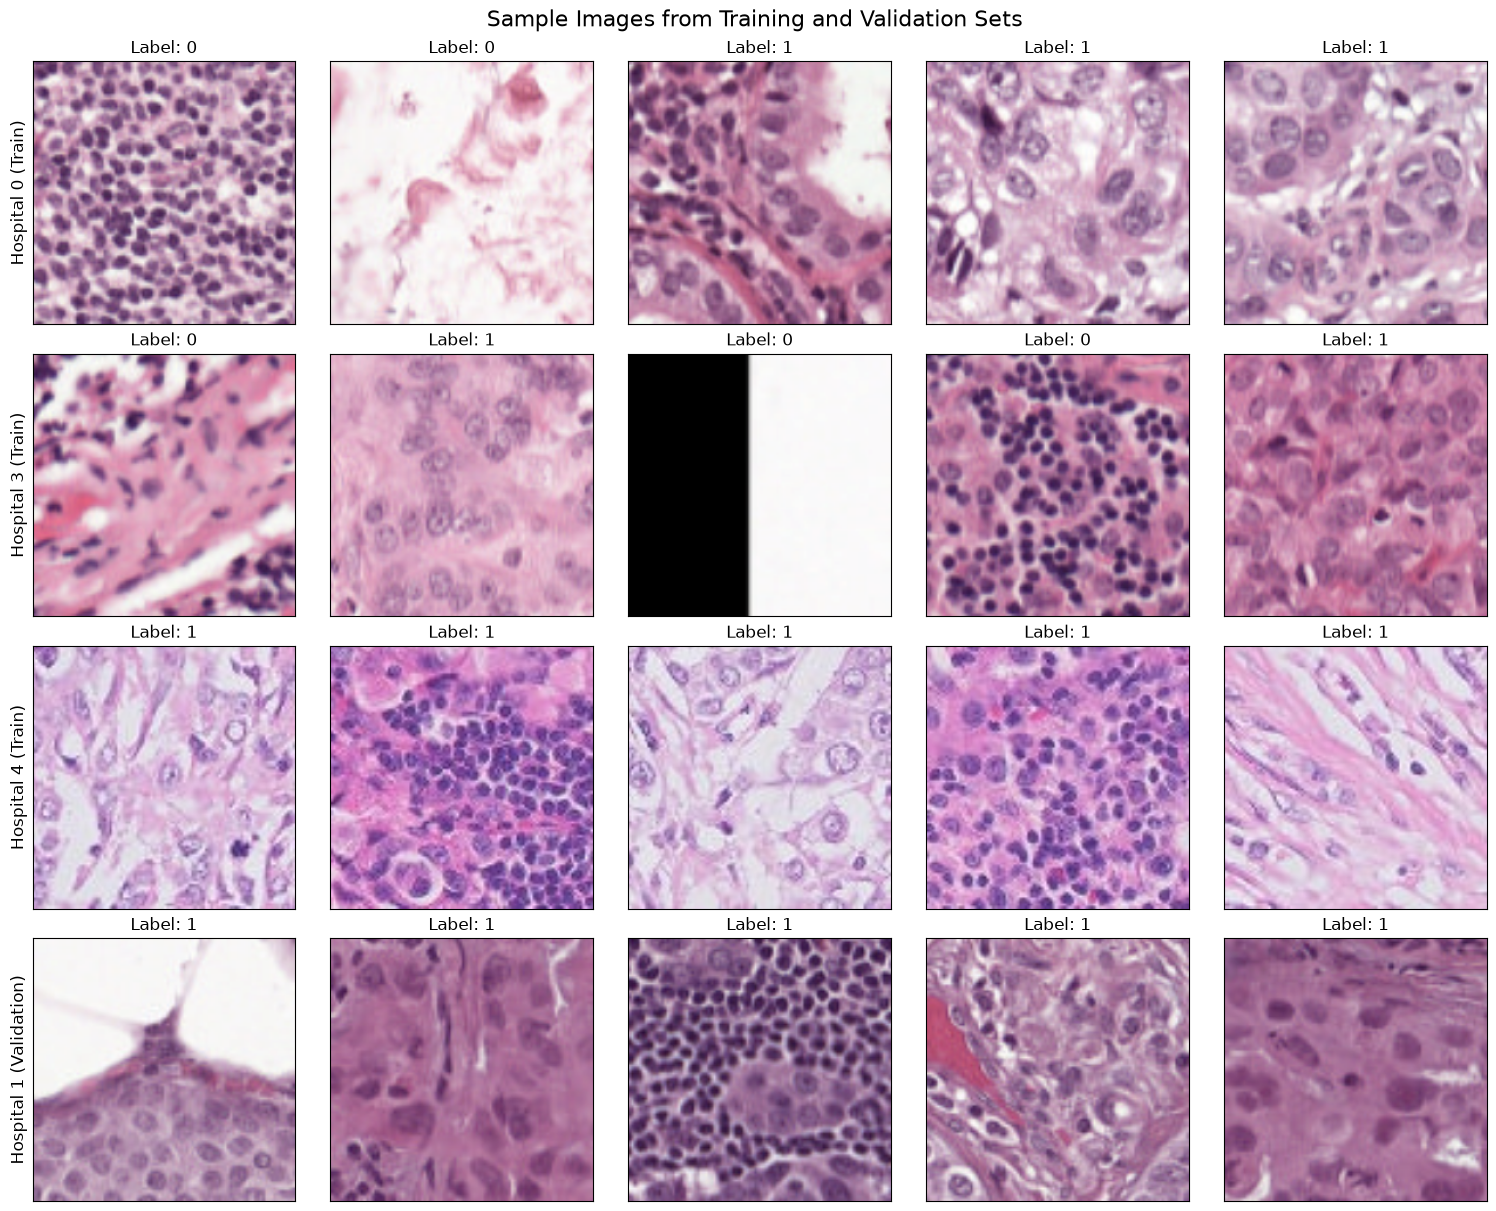

In [21]:
def denormalize(image: torch.Tensor) -> torch.Tensor:
    """Denormalizes an image tensor."""
    mean = torch.tensor([0.485, 0.456, 0.406], device=image.device).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=image.device).view(3, 1, 1)
    return (image * std + mean).permute(1, 2, 0)

n = 5

train_hospitals = torch.unique(train_data.metadata_array[:, 0])
val_hospitals = torch.unique(val_data.metadata_array[:, 0])

n_hospitals = len(train_hospitals) + len(val_hospitals)

fig, axes = plt.subplots(n_hospitals, n, figsize=(n * 3, n_hospitals * 3), constrained_layout=True)
for i, hospital in enumerate(train_hospitals):
    hospital_indices = torch.where(train_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Train)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= train_data[idx]
        axes[i, j].imshow(denormalize(image))  # Convert from (C, H, W) to (H, W, C)
        axes[i, j].set_title(f"Label: {label.item()}")

for i, hospital in enumerate(val_hospitals, start=len(train_hospitals)):
    hospital_indices = torch.where(val_data.metadata_array[:, 0] == hospital)[0]
    selected_indices = np.random.choice(hospital_indices, n, replace=False)

    axes[i, 0].set_ylabel(f"Hospital {hospital.item()} (Validation)", fontsize=12)

    for j, idx in enumerate(selected_indices):
        axes[i, j].set_yticks([])
        axes[i, j].set_xticks([])

        image, label, metadata= val_data[idx]
        axes[i, j].imshow(denormalize(image))
        axes[i, j].set_title(f"Label: {label.item()}")

fig.suptitle("Sample Images from Training and Validation Sets", fontsize=16)

plt.show()


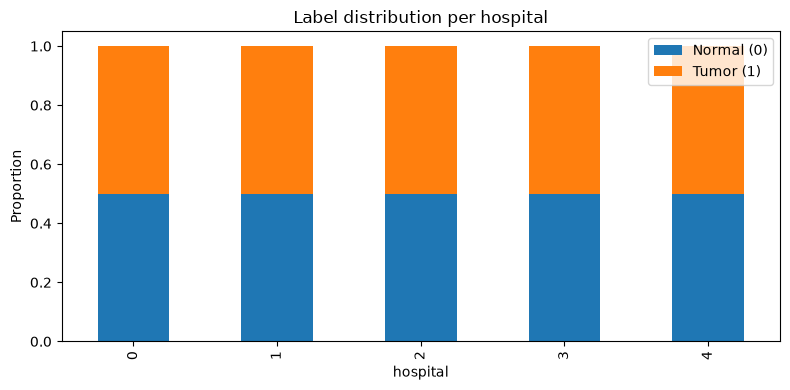

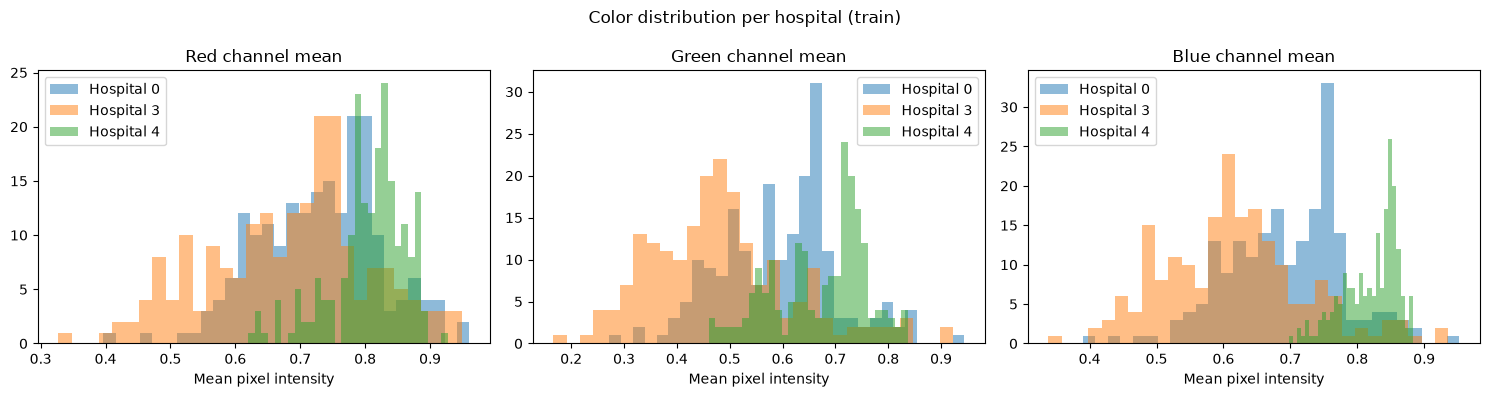

In [22]:
import pandas as pd

# ── 1. Distribuição de labels por hospital ──────────────────────────────────
hospitals_all = torch.cat([
    train_data.metadata_array[:, 0],
    val_data.metadata_array[:, 0],
    test_data.metadata_array[:, 0],
])
labels_all = torch.cat([train_data.y_array, val_data.y_array, test_data.y_array])
split_all = (["train"] * len(train_data)) + (["val"] * len(val_data)) + (["test"] * len(test_data))

df = pd.DataFrame({"hospital": hospitals_all.numpy(), "label": labels_all.numpy(), "split": split_all})
ct = df.groupby(["hospital", "label"]).size().unstack(fill_value=0)
ct_prop = ct.div(ct.sum(axis=1), axis=0)

ct_prop.plot(kind="bar", stacked=True, figsize=(8, 4))
plt.ylabel("Proportion")
plt.title("Label distribution per hospital")
plt.legend(["Normal (0)", "Tumor (1)"])
plt.tight_layout()
plt.show()

# ── 2. Distribuição de cor (RGB) por hospital ────────────────────────────────
n_samples_per_hospital = 200

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
channel_names = ["Red", "Green", "Blue"]

for hospital in torch.unique(train_data.metadata_array[:, 0]):
    idx = torch.where(train_data.metadata_array[:, 0] == hospital)[0]
    sample_idx = np.random.choice(idx, min(n_samples_per_hospital, len(idx)), replace=False)

    means = np.array([
        denormalize(train_data[i][0]).numpy().reshape(-1, 3).mean(axis=0)
        for i in sample_idx
    ])

    for c in range(3):
        axes[c].hist(means[:, c], bins=30, alpha=0.5, label=f"Hospital {hospital.item()}")

for c in range(3):
    axes[c].set_title(f"{channel_names[c]} channel mean")
    axes[c].set_xlabel("Mean pixel intensity")
    axes[c].legend()

plt.suptitle("Color distribution per hospital (train)")
plt.tight_layout()
plt.show()

A tarefa é classificar patches de tecido histopatológico corado com H&E em duas classes: normal ou tumoral. O que torna esse problema mais difícil do que uma classificação de imagens comum é a origem dos dados. O treino, a validação e o teste vêm de hospitais diferentes. Então o modelo não precisa só aprender a diferença entre tumor e tecido saudável, ele também precisa lidar com uma mudança de distribuição, já que vai ser avaliado num hospital (centro 2) que nunca apareceu durante o treino.
As primeiras imagens de amostra, já fornecidas no enunciado, mostram algo interessante. Os patches de hospitais diferentes têm tons de cor visivelmente distintos. O Hospital 4 tende a um roxo mais forte, enquanto o Hospital 0 aparece mais claro, com tons mais rosados. Também encontramos um patch corrompido, um artefato preto e branco, entre as amostras do Hospital 3, o que indica que o dataset tem algum ruído de qualidade.
Para confirmar essas impressões com números, fizemos duas análises adicionais. A primeira foi olhar a distribuição de labels por hospital. O resultado mostrou um balanceamento perfeito, com 50% normal e 50% tumor em todos os cinco hospitais. Isso já descarta desbalanceamento de classe como um problema no dataset.
A segunda análise foi sobre a distribuição de cor. Calculamos a intensidade média dos canais RGB de 200 imagens por hospital e comparamos os histogramas. O resultado ficou bem claro: cada hospital tem uma espécie de assinatura de cor própria. No canal azul, por exemplo, o Hospital 4 se concentra perto de 0.85, enquanto o Hospital 3 fica perto de 0.6, e os dois histogramas quase não se sobrepõem. Isso faz sentido, já que cada hospital usa seu próprio scanner e protocolo de coloração. Mas isso traz uma consequência importante: só olhando para a cor média de uma imagem, já daria para adivinhar de qual hospital ela veio.


Esse achado aponta para o principal desafio do problema. A cor está fortemente ligada ao hospital de origem, mas não tem nenhuma relação real com a presença de tumor. Existe o risco de a rede aprender um atalho, associando certos tons de cor a um rótulo só porque essa associação aparece por acaso no conjunto de treino, em vez de aprender as características morfológicas que realmente importam, como densidade nuclear e arquitetura do tecido. Um atalho desse tipo funciona bem enquanto o modelo é testado nos mesmos hospitais do treino, mas tende a falhar no hospital 2, cuja cor nunca foi vista antes.
A partir disso, nossa hipótese inicial é que a rede deve ter um bom desempenho dentro da distribuição de treino, mas provavelmente vai apresentar uma queda de desempenho perceptível no hospital de teste, na medida em que o modelo depender de cor em vez de morfologia. Se essa hipótese estiver certa, técnicas que reduzam a dependência de cor, como mudanças de arquitetura ou pré processamento, devem ajudar a diminuir essa queda.
Por fim, sobre se a rede vai conseguir generalizar, acreditamos que sim, mas só parcialmente. A morfologia do tumor é um sinal real e está presente em todos os hospitais, então uma rede convolucional bem treinada deve capturar parte desse sinal, garantindo um desempenho acima do acaso mesmo no hospital nunca visto. Ao mesmo tempo, dada a separação de cor tão evidente entre os hospitais, também esperamos que o desempenho fora de distribuição seja visivelmente pior do que dentro de distribuição. Essa diferença seria um indício de que o modelo está, pelo menos em parte, se apoiando na cor em vez da morfologia, e é justamente essa hipótese que pretendemos testar de forma mais rigorosa nos experimentos seguintes, inclusive testando diretamente o efeito de remover a cor das imagens.

*YOUR ANSWER HERE*

---

## Experiment 1: Transfer Model (Baseline)

[ResNet-18](https://arxiv.org/abs/1512.03385) is a convolutional neural network pretrained on ImageNet, a large-scale dataset of natural images spanning 1,000 object categories.
It is one of the most widely used backbones in transfer-learning pipelines due to its representation capacity across a broad domain of images.
Although it is often treated as a generic feature extractor, its architecture embeds several structural assumptions about images, which become encoded in the learned weights.
When transferring the model to histopathology, it is not immediately clear which of these assumptions remain useful, which are irrelevant, and which may even be harmful.

> **Question:**
>
>What inductive biases does a pretrained ResNet-18 inherit from pretraining on ImageNet, and do they transfer to histopathology?

> **Hypothesis:** 
>
> A pretrained ResNet-18 encodes local visual structures via hierarchical convolutional filters that generalize beyond natural images.
> As a result, a **linear classifier** trained on top of *frozen* ResNet features (a linear probe) should achieve accuracy substantially above 50% on both ID validation and OOD test data, despite the large domain gap between natural and histopathology images.

> **Baseline:**
>
> Random chance is 50% accuracy for balanced binary classification.

In [ ]:
# Representation cached from the ResNet-18 backbone

backbone = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
backbone.fc = nn.Identity()  # Remove the final classification layer to get features instead of predictions.

train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

with torch.no_grad():
    backbone.eval()
    backbone.to(DEVICE)

    train_features = []
    train_labels = []
    for images, labels, _ in train_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        train_features.append(features)
        train_labels.append(labels)

    val_features = []
    val_labels = []
    for images, labels, _ in val_loader:
        images = images.to(DEVICE)
        features = backbone(images).cpu()
        val_features.append(features)
        val_labels.append(labels)


resnet_train_dataset = TensorDataset(torch.cat(train_features), torch.cat(train_labels))
resnet_val_dataset = TensorDataset(torch.cat(val_features), torch.cat(val_labels))

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jubsventi/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:01<00:00, 43.0MB/s]


In [ ]:
# You can modify the following methods as you want.

def train_model(
    model: nn.Module,
    train_loader: DataLoader,
    criterion: nn.Module,
    optimizer: optim.Optimizer,
    n_epochs: int,
    ... # Add any additional arguments, like validation loader, early stopping criteria, etc.
) -> dict[str, list[float]]:
    """Trains the model and returns the training history."""
    history = {
        "loss": [],
        ...
    }

    for epoch in range(n_epochs):
        model.train()
        epoch_loss = 0.0
        n_batches = len(train_loader)

        for batch, (images, labels, _) in enumerate(train_loader):
            images, labels = images.to(DEVICE), labels.float().to(DEVICE).unsqueeze(1).to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            history["loss"].append(loss.item())

            perc = (batch + 1) / n_batches
            print(f"Epoch {epoch + perc:.2f}/{n_epochs}, Batch Loss: {loss.item():.4f}", end="\r")

            epoch_loss += loss.item() * images.size(0)

        epoch_loss /= len(train_loader.dataset)
        print(f"Epoch {epoch+1}/{n_epochs}, Loss: {epoch_loss:.4f}                            ")

    return history

def evaluate_model(model: nn.Module, data_loader: DataLoader) -> dict[str, float]:
    """Evaluates the model on the given data loader and returns the AUC-ROC score."""
    model.eval()
    all_labels = []
    all_probs = []

    with torch.no_grad():
        for images, labels, _ in data_loader:
            images = images.to(DEVICE)
            outputs = model(images)
            probs = torch.sigmoid(outputs).cpu().numpy()
            all_probs.extend(probs.flatten())
            all_labels.extend(labels.numpy().flatten())

    auc_roc = float(roc_auc_score(all_labels, all_probs))

    return {
        "auc_roc": auc_roc,
        ...
    }


In [ ]:
class LinearProbe(nn.Module):
    """Linear probe on top of the ResNet-18 backbone."""
    def __init__(self, input_dim: int, num_classes: int) -> None:
        super().__init__()
        self.fc = nn.Linear(input_dim, num_classes)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.fc(x)

In [ ]:
train_loader = DataLoader(resnet_train_dataset, batch_size=128, shuffle=True, num_workers=4)
val_loader = DataLoader(resnet_val_dataset, batch_size=128, shuffle=False, num_workers=4)

model = LinearProbe(input_dim=..., num_classes=1).to(DEVICE)

optimizer = ...
criterion = ...

history = train_model(model, train_loader, criterion, optimizer, n_epochs=5)

In [ ]:
# Evaluate the model on the validation set, and also visualize the training history (e.g., plot the loss curve).
# You can also plot additional figures to help you analyze the results. Examples include:
# - AUC-ROC curve
# - Confusion matrix
# - Use a dimensionality reduction technique (e.g., t-SNE, PCA) to visualize the ResNet learned representations.

### Design justification

> **Question.** (1.0 pts)
> 
> Why changing only the last layer of the pretrained ResNet-18 is a reasonable baseline for this dataset?
>
> Explain what were the metrics that you used to test the hypothesis and why they help answering the question.

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using a frozen backbone. Address the following points:
> 
> Do the results support or contradict the hypothesis? Refer to specific numbers.
>
> What does the gap between metrics ID vs OOD imply about the representations?
>
> What limitations does the linear probe evaluation have when assessing the quality of the pretrained representations?
> Can we correctly attribute what is causing the observed performance?

*YOUR ANSWER HERE*

---

## Experiment 2: Is the CNN Structure Necessary?

ResNet is a convolutional architecture, meaning it builds in several strong assumptions: 
- local feature detection via small kernels
- spatial weight sharing
- hierarchical composition of features

These are not universal truths about image data, they are inductive biases that may or may not be useful for a given task.

A model with no spatial inductive bias, such as a multilayer perceptron (MLP) applied to flattened pixels, treats every pixel independently and must learn spatial relationships from data alone.
Comparing the two isolates the contribution of the convolutional inductive bias from all other factors.

This comparison also illustrates a central theme of this assignment: **raw parameter count does not determine generalization**.
As you will see, the MLP on 96×96×3 input has a first hidden layer alone with more parameters than the entire CNN, yet it may perform worse, demonstrating that inductive alignment with the data structure matters more than model capacity.

Note that, as we changed a lot of things when compared with the previous experiment, we cannot make a direct comparison, but we can see the performance on a baseline that already solves the problem.

> **Question:** Does the spatial inductive bias of a convolutional architecture improve generalization over a non-spatial model with comparable or greater parameter count?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should make a concrete, directional prediction about the ID accuracy, OOD accuracy, and/or ID–OOD gap for the MLP vs SmallCNN. Refer to specific structural properties you expect to matter.*



*YOUR ANSWER HERE*

In [ ]:
class MLP(nn.Module):
    """Fully connected network."""

    def __init__(self, ...) -> None:
        super().__init__()
        # TODO: Build a sequential MLP.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Flatten x to (batch, input_size) before the MLP layers.

        return x


class SmallCNN(nn.Module):
    """Small convolutional network, spatial inductive bias."""

    def __init__(self, ...) -> None:
        super().__init__()
        # TODO: Build a small CNN with the following structure:
        #   3 convolutional blocks, each: Conv2d → BatchNorm2d → Activation → MaxPool2d(2)
        #   Choose any activation function you want (e.g., ReLU, LeakyReLU, GELU).
        #   The channel widths can be of your choice, but we recommend something like 3 → 32 → 64 → 128.
        #   The last block should be followed by: AdaptiveAvgPool2d(1) → Flatten → Linear.

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # TODO: Implement the forward pass through the CNN.

        return x


In [ ]:
# For this experiment, you can change the data transforms if you want.
# We recommend using smaller input sizes (e.g., the raw data is 96×96)
# for the MLP and SmallCNN, since they have fewer parameters than the ResNet-18
# and will overfit more easily on the full 224×224 images.
# You can use the same normalization as before, or recompute the mean and std
# on the smaller input size.

SIZE = 96

transform = transforms.Compose(
    [
        # You can uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]), 
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
mlp_input_dim = SIZE * SIZE * 3  # 96 × 96 × 3 = 27,648

mlp = MLP(input_size=mlp_input_dim, hidden_dims=[512, 256])
cnn = SmallCNN()


def count_params(model: nn.Module) -> int:
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


print(f"MLP total parameters : {count_params(mlp):>12,}")
print(f"CNN total parameters : {count_params(cnn):>12,}")
print()
print("Note: both models receive the same 96×96×3 input and the same training procedure.")

In [ ]:
train_loader = get_train_loader("standard", train_data, batch_size=128, num_workers=4)
val_loader = DataLoader(val_data, batch_size=128, shuffle=False, num_workers=4)

# Hint: Even though the models are different, you can use the same training loop and the same hyperparameters
# (e.g., learning rate, optimizer, number of epochs) for both models to make a fair comparison.
# You can also do hyperparameter tuning for each model separately if you want.

# The important thing is to ensure that both models are trained under similar conditions, or that both
# are given the opportunity to perform their best (e.g., by tuning hyperparameters separately).
# If your CNN, for example, performs much better than the MLP, but they were trained with very different setups,
# it is harder to convincingly argue that the CNN's superior performance is due to its architecture rather than the training procedure.

learning_rate = ...
n_epochs = ...
dropout = ...

In [ ]:
mlp_optimizer = ...
mlp_criterion = ...

train_mlp_history = train_model(mlp, train_loader, mlp_criterion, mlp_optimizer, n_epochs=n_epochs)

In [ ]:
cnn_optimizer = ...
cnn_criterion = ...

# CNN training might be slower than MLP training, so you can reduce the number of epochs for the CNN if needed.
train_cnn_history = train_model(cnn, train_loader, cnn_criterion, cnn_optimizer, n_epochs=n_epochs)

In [ ]:
# Plot the training history (e.g., loss curves) for both models, and evaluate their performance on the validation set.
# You can also plot additional figures to help you analyze the results. Examples include:
# - AUC-ROC curve
# - Confusion matrix
# - Use a dimensionality reduction technique (e.g., t-SNE, PCA) to visualize the learned representations of the models.
# - You can also visualize the learned filters of the CNN, or the activations of the intermediate layers, to gain insights into what the CNN is learning.
# - Or the first layer weights of the MLP, reshaped to 96×96 images, to see if it is learning any meaningful patterns.

### Design justification

> **Question.** (1.0 pts)
>
> Why comparing MLP vs SmallCNN (both trained from scratch on the same data) isolates the contribution of the convolutional inductive bias?
> 
> What aspect of the your implementation makes it an atomic ablation?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of using MLP vs CNN in generalization. Address the following points:
> 
> Do the results support or contradict your hypothesis? Refer to specific metric values.
>
> Compare the ID–OOD gap for MLP vs CNN. Which model generalizes better to the unseen center, and why might that be?
>
> The MLP has more parameters than the CNN, did this fact influenced the generalization aspect of the MLP?
>
> How do the from-scratch models compare to the frozen ResNet from Experiment 1?

*YOUR ANSWER HERE*

---

## Experiment 3: Are Colors a Required Feature?

A potential issue in the data is that, different hospitals use different techniques for collecting data.
One example of such change is how the stain intensity shift across hospital centers.

Because each center has a different scanner and staining protocol, the color distribution of a patch partially encodes which hospital it came from.
This creates a potential **spurious correlation**: a model trained on centers 0–2 may learn to use color as a predictive cue, even though color is determined by the imaging center rather than by tumor status.

Under center shift (training on centers 0–2, testing on center 4), a model that relies on color will encounter a new color distribution and may fail even if the morphological signal is present.

> **Question:** Does the previous CNN rely on color information to predict tumor status, and does removing color change the generalizaion gap?

### Hypothesis

> **Hypothesis.** (1.0 pts)
>
> *State a falsifiable hypothesis. Your hypothesis should predict the direction of the change in ID accuracy, OOD accuracy, and/or ID–OOD gap when switching from RGB to grayscale input. Relate your prediction to the color distribution visualization from the Data Exploration section.*

*YOUR ANSWER HERE*

In [ ]:
# Maintain the same configurations you set on the previous cells (e.g. input size, normalization, etc.) to
# isolate the effect of changing the data assumptions.

transform = transforms.Compose(
    [
        # Uncomment the line below if you want to use a different input size.
        # transforms.Resize((SIZE, SIZE)),
        transforms.Grayscale(num_output_channels=3),  # Convert to 3-channel grayscale to use the same architecture as before.
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5]),
    ]
)

train_data = dataset.get_subset("train", transform=transform)
val_data = dataset.get_subset("val", transform=transform)
test_data = dataset.get_subset("test", transform=transform)

In [ ]:
# Your code here
# Train, evaluate and analyze.

### Design justification

> **Question.** (1.0 pts)
>
> Explain your experiment configuration, state what remained the same from the previous experiment, and what have changed.
>
> How does your experiment answer the question?

*YOUR ANSWER HERE*

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results of removing the color feature. Address the following points:
> 
> Does removing color improve or degrade ID metrics? OOD metrics? Was this consistent with your hypothesis?
>
> Can we attribute the results uniquely to the color change?
>
> How does it connect with the Data exploration you conducted?

*YOUR ANSWER HERE*

---

## Model Selection: Choosing the final model

The three previous experiments provide evidence about what drives and what hinders generalization in this setting:

- **Experiment 1** established the baseline: a linear probe on frozen pretrained features achieves some performance, with a measurable ID–OOD gap.
- **Experiment 2** assessed whether spatial inductive bias matters.
- **Experiment 3** assessed whether color is a spurious or informative feature.

In this experiment you will use those observations to motivate a final model of your choice and test whether it generalizes for the test dataset.

You don't need to state a hypothesis, or justify your design here.
Experiment with different settings and suppositions until you converge with the best model that might well generalize.
You can use ResNet, or a network from scratch, just report the number of parameters on the final model and the time it took to
train.

> **Question**
>
> Based on the evidence from previous experiments, propose a deep neural network that might reduce the ID–OOD generalization gap.

In [ ]:
# TODO: Implement your final model (you can choose any architecture you want, including the ones you implemented before) and train it on the dataset.
# Some suggestions:
# - You can use the ResNet-18 backbone from Experiment 1 and fine-tune all (or the last N) layers instead of freezing them.
# - You can use the MLP or SmallCNN from Experiment 2 and increase their capacity (e.g., more layers, more hidden units, etc.).
# - You can change the data transforms (e.g., input size, normalization, data augmentation, etc.) to see if it improves the performance of the models.
# - You can use other loss functions (e.g., focal loss, dice loss, etc.) or optimization algorithms (e.g., AdamW, RMSProp, etc.).
# - A combination of the above suggestions (caution to not change too many things at once, or it will be harder to analyze the results and understand what caused the performance changes).

In [ ]:
# Evaluate your final model, analyze the results.
# Use the same evaluation metrics and plots you used in the previous experiments to analyze the performance of your final model.
# Now, you can also evaluate your final model on the test set, but make sure to only do this after you have finalized your model
# and analysis based on the validation set, to avoid overfitting to the test set.

### Discussion

> **Question.** (1.0 pts) 
> 
> Discuss the results for your final model.
> 
> What is the number of parameters of your model? Compare it with the size of the previous models and draw a link with the results.
>
> What was the training time? Did it take more or less time than the expected?
>
> How does the OOD performance connect with your changes in the data and model?
>
> If your results are positive, can you attribute for certain which aspect of your model mostly contributed for the increase in performance?
> 
> Conversely, if your results are negative (the modification were worse than the experiments), provide an alternative explanation that is consistent with the failure.

*YOUR ANSWER HERE*

---

## Assignment Submission

This notebook must be filled with your solution and submitted on the Assignment's entry at our Google Classroom page.

Before submitting, verify that:
- The notebook runs end-to-end without errors (use **Run All** after restarting the kernel).
- All plots are rendered in the output.
- All written section (Hypothesis, Design, Discussion) are filled in.
- AI usage declaration and prompts are included, if applicable.

**Important: Only one member of the group should submit.**

### Policy for late submissions

You are NOT encouraged to submit after the deadline; however, in this case the following penalties apply:

- 25% deduction for 1-day late submission.
- 50% deduction for 2-day late submission.
- 75% deduction for 3-day late submission.